# Тема 7. Обучение без учителя: PCA и кластеризация

## Занятие 7 (теория)

**В `lesson02_visual_advanced.ipynb` мы мельком показали PCA и t-SNE** как способ взглянуть на весь датасет оттока сразу — сжали все признаки в 2D и раскрасили по `Churn`. Сегодня разберём, что там происходит внутри, и добавим вторую большую тему **обучения без учителя** — кластеризацию: что если вообще забыть про `Churn` и попробовать найти естественные группы клиентов самим?

**План занятия:** метод главных компонент (PCA) — идея и практика → PCA как предобработка → k-Means → сегментация клиентов оттока без разметки → выбор числа кластеров.

**Практика** — в `lesson07_unsupervised_practice.ipynb` (Titanic — сегментация пассажиров).
**Дополнительно** (кластеризация текстов и лиц, другие алгоритмы кластеризации) — в `lesson07_unsupervised_advanced.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

%config InlineBackend.figure_format = 'svg'
RANDOM_STATE = 42

---
## 1. Метод главных компонент (PCA): идея

PCA ищет направления в пространстве признаков, вдоль которых данные **разбросаны сильнее всего** (наибольшая дисперсия), и проецирует данные на несколько первых таких направлений («главные компоненты»). Это **сжатие**: было много признаков — осталось немного новых, каждый из которых — линейная комбинация исходных. Смысла отдельной оси обычно нет («компонента 1 — это что?» без содержательного ответа), но геометрия (кто на кого похож) сохраняется настолько хорошо, насколько это вообще возможно в 2-3 измерениях.

Классическая демонстрация — рукописные цифры (8×8 = 64 признака-пикселя на изображение). Сожмём в 2D:

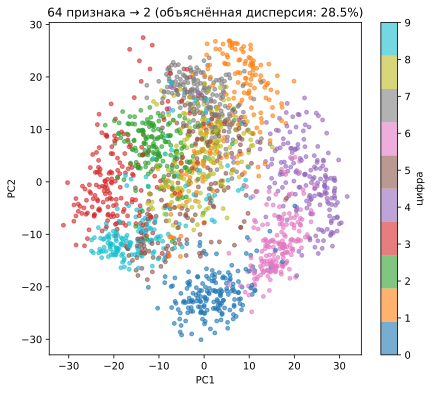

In [2]:
digits = load_digits()
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(digits.data)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=digits.target, cmap="tab10", alpha=0.6, s=15)
plt.colorbar(scatter, label="цифра")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"64 признака → 2 (объяснённая дисперсия: {pca.explained_variance_ratio_.sum():.1%})");

Даже без единой подписи «это цифра 0» модель **никогда не видела** — просто сжатие 64 чисел в 2 — одинаковые цифры оказались рядом друг с другом. Это и есть то, что мы искали глазами через `pairplot` в теме 2: структура в данных, которую не видно по одному признаку за раз.

---
## 2. Сколько компонент оставить?

2 компоненты — только для картинки. На практике смотрят на **долю объяснённой дисперсии** в зависимости от числа компонент и берут столько, сколько нужно, чтобы сохранить приемлемую долю (например, 90%):

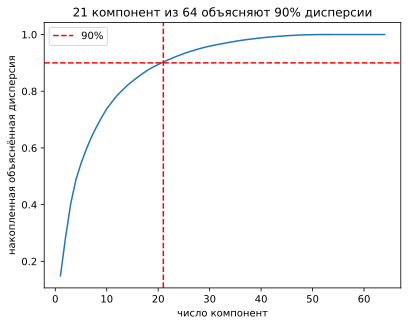

In [3]:
pca_full = PCA(random_state=RANDOM_STATE).fit(digits.data)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(cumulative >= 0.9) + 1

plt.plot(range(1, len(cumulative) + 1), cumulative)
plt.axhline(0.9, color="red", linestyle="--", label="90%")
plt.axvline(n_90, color="red", linestyle="--")
plt.xlabel("число компонент")
plt.ylabel("накопленная объяснённая дисперсия")
plt.legend()
plt.title(f"{n_90} компонент из 64 объясняют 90% дисперсии");

21 компонента из 64 сохраняют 90% дисперсии — почти трёхкратное сжатие почти без потерь. Заметно круче падает график в начале: первые компоненты «ловят» самую крупную структуру, дальше идут всё более мелкие детали и шум.

---
## 3. PCA как предобработка

Раз 21-30 компонент сохраняют почти всю структуру данных, можно обучать модель **не на исходных 64 признаках, а на сжатых** — быстрее, а иногда и точнее (PCA заодно отфильтровывает часть шума, ведь шум обычно не образует крупных направлений дисперсии).

In [4]:
X_train, X_valid, y_train, y_valid = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=RANDOM_STATE
)

import time
t0 = time.time()
svc_full = SVC().fit(X_train, y_train)
acc_full, time_full = svc_full.score(X_valid, y_valid), time.time() - t0

pca30 = PCA(n_components=30, random_state=RANDOM_STATE).fit(X_train)
X_train_30, X_valid_30 = pca30.transform(X_train), pca30.transform(X_valid)
t0 = time.time()
svc_pca = SVC().fit(X_train_30, y_train)
acc_pca, time_pca = svc_pca.score(X_valid_30, y_valid), time.time() - t0

print(f"64 признака:  accuracy={acc_full:.4f}, время обучения={time_full:.3f}с")
print(f"30 компонент: accuracy={acc_pca:.4f}, время обучения={time_pca:.3f}с (дисперсии сохранено {pca30.explained_variance_ratio_.sum():.1%})")

64 признака:  accuracy=0.9870, время обучения=0.032с
30 компонент: accuracy=0.9926, время обучения=0.045с (дисперсии сохранено 95.9%)


Сжатая версия обучилась быстрее **и** оказалась чуть точнее полной — меньше признаков, меньше шума, которому модель могла бы случайно подстроиться.

---
## 4. Кластеризация: k-Means

**Кластеризация** — в отличие от всего, что мы делали до сих пор, не использует целевую переменную вообще. Задача: разбить объекты на группы так, чтобы объекты внутри группы были похожи друг на друга, а между группами — различались.

**Алгоритм k-Means:**
1. Случайно ставим `k` «центров» кластеров.
2. Каждую точку относим к ближайшему центру.
3. Пересчитываем каждый центр как среднее точек, отнесённых к нему.
4. Повторяем шаги 2-3, пока центры не перестанут заметно двигаться.

Применим к тем же цифрам, попросив ровно 10 кластеров (не говоря модели, что цифр 10, — просто интересное совпадение для проверки):

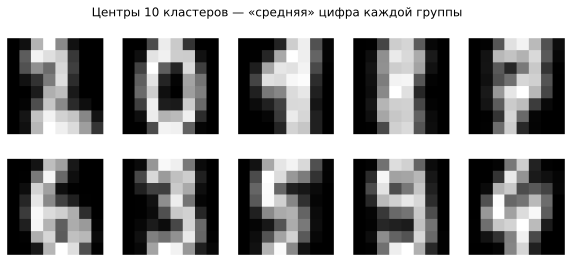

In [5]:
km_digits = KMeans(n_clusters=10, random_state=RANDOM_STATE, n_init=10)
km_digits.fit(digits.data)

_, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, center in zip(axes.ravel(), km_digits.cluster_centers_):
    ax.imshow(center.reshape(8, 8), cmap="gray")
    ax.axis("off")
plt.suptitle("Центры 10 кластеров — «средняя» цифра каждой группы");

Модель никогда не видела подписи «это семёрка» — но, усредняя похожие изображения внутри найденных ею кластеров, получила нечто похожее на настоящие цифры. Похожие объекты действительно оказались рядом в пространстве признаков, кластеризация это уловила.

---
## 5. Сегментация клиентов оттока — без единого взгляда на `Churn`

Вернёмся к датасету оттока. Забудем про `Churn` полностью и попробуем найти естественные группы клиентов по остальным признакам — а потом, только для проверки, посмотрим, различается ли реальный отток между найденными группами (кластеризация его не видела).

In [6]:
df = pd.read_csv("../data/telecom_churn.csv")
df["Churn"] = df["Churn"].astype(int)
df["International plan"] = (df["International plan"] == "Yes").astype(int)
df["Voice mail plan"] = (df["Voice mail plan"] == "Yes").astype(int)
X = df.drop(columns=["State", "Churn"])  # Churn сюда сознательно не идёт
X_scaled = StandardScaler().fit_transform(X)

km4 = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = km4.fit_predict(X_scaled)

df.groupby("cluster")["Churn"].agg(["mean", "count"]).rename(columns={"mean": "доля оттока"})

,доля оттока,count
cluster,,
0,0.187621,1034
1,0.093669,1153
2,0.053463,823
3,0.424149,323


Один из четырёх сегментов (примерно 10% клиентов) оттекает почти в **8 раз чаще** остальных — а мы ни разу не показали алгоритму колонку `Churn`. Значит, «рискованный» профиль клиента виден по остальным признакам достаточно чётко, что его можно найти даже вслепую. На практике так ищут сегменты для точечных маркетинговых кампаний (в отличие от дерева/леса, кластеризация не говорит «кто уйдёт», но говорит «кто на кого похож»).

---
## 6. Сколько кластеров брать?

Мы взяли `k=4` без обоснования. **Силуэт (silhouette score)** — метрика от −1 до 1: для каждой точки сравнивает, насколько она ближе к своему кластеру, чем к соседнему; среднее по всем точкам. Больше — лучше.

**Задание преподавателю на занятии:** для `k` от 2 до 6 обучите `KMeans` на `X_scaled` и посчитайте `silhouette_score`. Постройте график.

In [ ]:
# for k in range(2, 7):
#     km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
#     print(k, silhouette_score(X_scaled, km.labels_))


Наилучший силуэт обычно оказывается при `k=2` — самое грубое разбиение почти всегда «чище» (меньше проникновения кластеров друг в друга), чем более дробное. Но `k=2` здесь просто заново находит самый сильный бинарный признак (`Voice mail plan` — разбиение получается практически идеально по нему), а не рискованный сегмент, который дал `k=4`.

**Вывод:** силуэт — полезный ориентир, но не заменяет здравый смысл и бизнес-интерпретацию. Иногда чуть менее «чистое» по метрике разбиение содержательнее.

---
## Итог занятия

Сегодня разобрали:

- PCA: сжатие признаков вдоль направлений наибольшей дисперсии, выбор числа компонент по объяснённой дисперсии
- PCA как предобработку — быстрее и иногда точнее, чем работа с исходными признаками
- k-Means: алгоритм, применение к цифрам и к сегментации клиентов оттока без учителя
- Силуэт для выбора `k` — и его пределы (не всегда лучшая метрика = самый полезный результат)

**Дальше:**
- Практика — `lesson07_unsupervised_practice.ipynb` (Titanic: сегментация пассажиров)
- Доп. материалы — `lesson07_unsupervised_advanced.ipynb`
- Следующее занятие — градиентный бустинг: последний и самый сильный инструмент в нашем курсе для задачи оттока